# Gridsynth

The main task of `gridsynth` is to take
$$
R_Z(\theta) = 
\begin{pmatrix}
\mathrm{e}^{-i\theta/2} & 0 \\
0 & \mathrm{e}^{i\theta/2}
\end{pmatrix}
$$

and find a circuit that roughly implements this rotation
$$
R_Z(\theta) = C_1T^{k_1}C_2T^{k_2}\dots C_n
$$

where the $C_i$'s are the Clifford operations and the $T$ gates are the non-clifford gates. In the paper they specify bits of accuracy, which essentially means choosing an error target of $\epsilon \sim 2^{-b}$ where b is the number of bits. They state the scaling is typically
$$
\text{Number of Clifford gates} = 3\log_2 \left(\frac1\epsilon\right) + O\left(\log\left(\log\left(\frac1\epsilon\right)\right)\right)
$$

which means roughly $3b$ T gates. In the paper, they vary the accuracy from 1 to 32 bits, which means we're essentially doing:
```py
for b = 1, 2, ..., 32:
    epsilon = 2^(-b)

    for i = 1, ..., 1000:
        generate QPE circuit
        find every RZ(theta)
        replace each RZ(theta) with a Gridsynth approximation
             at accuracy epsilon

        simulate the resulting Clifford+T circuit
        repeat measurement 10,000 times
``` 

The software is available in python in the form of `pygridsynth` which will be our main tool.

In [141]:
import pygridsynth as gs
import numpy as np
import matplotlib.pyplot as plt
import mpmath

import qutip as q
from qutip_qip.circuit import QubitCircuit
from qutip_qip.operations import Gate, hadamard_transform
from pygridsynth.gridsynth import gridsynth_circuit
from pygridsynth.quantum_gate import HGate,TGate,SGate,SXGate,WGate

First, we reuse the code form `Trotterization-QPE.ipynb` with slight changes. We replace the custom gates with their exact Clifford + single-qubit RZ decompositions. Using θ=t/2, the ZZ rotation is implemented as CNOT → RZ(theta) → CNOT, while the ZX rotation is implemented as H → CNOT → RZ(theta) → CNOT → H on the appropriate qubits. The QPE circuit now explicitly contains these decomposed gates instead of the original custom two-qubit matrix gates; the decomposition is still exact, so no approximation has been introduced yet. The next step is to simplify the repeated ZZ → ZX → ZX → ZZ sequence before replacing the RZ gates with Gridsynth approximations.

In [142]:
X = q.sigmax()
Z = q.sigmaz()
I = q.qeye(2)

c1 = 0.78796736
c2 = 0.18128881

t = np.pi / (c1 + c2)
theta = t / 2

def rz(theta):
    return (-1j * theta * Z / 2).expm()

def cnot():
    P0 = (I + Z) / 2
    P1 = (I - Z) / 2
    return (q.tensor(P0, I) + q.tensor(P1, X))

CNOT = cnot()
RZ = q.tensor(I, rz(theta))
H = hadamard_transform(1)

ZZ_decomposed = CNOT * RZ * CNOT
ZX_decomposed = (q.tensor(I, H) * ZZ_decomposed * q.tensor(I, H))

In [156]:
def generate_qpe_circuit():
    qc = QubitCircuit(4)
    qc.add_gate("H", targets=0)
    qc.add_gate("H", targets=1)
    qc.add_gate("H", targets=2)
    qc.add_gate("X", targets=3)

    for i in range(3):
        power = 2 ** i
        angle = power * theta

        qc.add_gate("CNOT", controls=i, targets=3)
        qc.add_gate("RZ", targets=3, arg_value=angle)
        qc.add_gate("CNOT", controls=i, targets=3)

        qc.add_gate("H", targets=3)
        qc.add_gate("CNOT", controls=i, targets=3)
        qc.add_gate("RZ", targets=3, arg_value=angle)
        qc.add_gate("CNOT", controls=i, targets=3)

        qc.add_gate("CNOT", controls=i, targets=3)
        qc.add_gate("RZ", targets=3, arg_value=angle)
        qc.add_gate("CNOT", controls=i, targets=3)
        qc.add_gate("H", targets=3)

        qc.add_gate("CNOT", controls=i, targets=3)
        qc.add_gate("RZ", targets=3, arg_value=angle)
        qc.add_gate("CNOT", controls=i, targets=3)

    qc.add_gate("SWAP", targets=[0, 2])
    qc.add_gate("H", targets=2)
    qc.add_gate("CPHASE", controls=2, targets=1, arg_value=-np.pi / 2)
    qc.add_gate("H", targets=1)
    qc.add_gate("CPHASE", controls=2, targets=0, arg_value=-np.pi / 4)
    qc.add_gate("CPHASE", controls=1, targets=0, arg_value=-np.pi / 2)
    qc.add_gate("H", targets=0)

    return qc

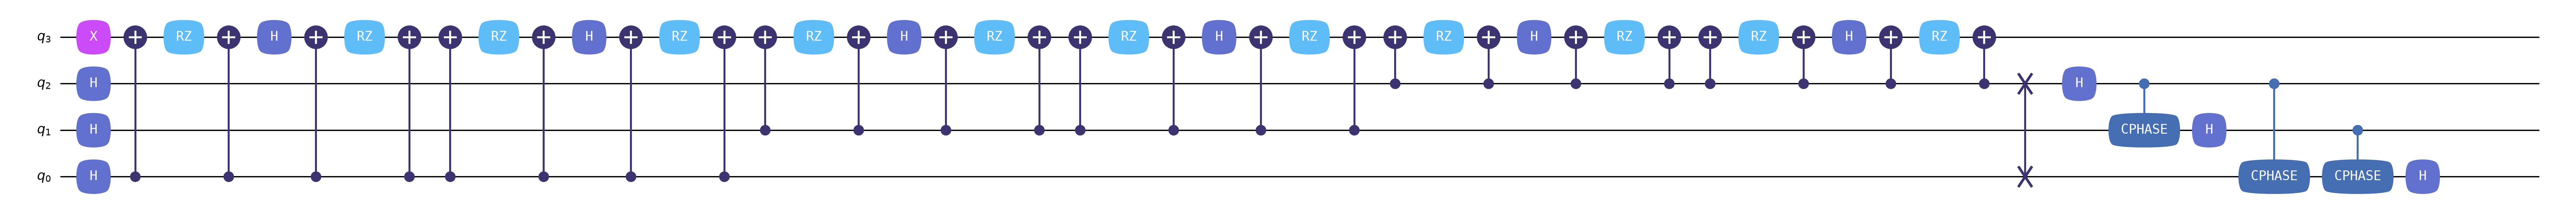

In [144]:
qc = generate_qpe_circuit()

qc.draw("matplotlib", dpi=300)

Now, we need a small helper function

In [146]:
def add_gridsynth_rz(qc,target,theta,bits):
    epsilon=mpmath.mpf(2)**(-bits)
    circuit=gridsynth_circuit(theta=theta,epsilon=epsilon,wires=[0],up_to_phase=True)
    for gate in reversed(circuit):
        if isinstance(gate,HGate):
            qc.add_gate("H",targets=target)
        elif isinstance(gate,TGate):
            qc.add_gate("T",targets=target)
        elif isinstance(gate,SGate):
            qc.add_gate("S",targets=target)
        elif isinstance(gate,SXGate):
            qc.add_gate("X",targets=target)
        elif isinstance(gate,WGate):
            continue
        else:
            raise TypeError(f"Unknown Gridsynth gate: {type(gate).__name__}")

And another helper for CPHASE:

In [147]:
def add_cphase_decomposition(qc,control,target,theta,bits):
    add_gridsynth_rz(qc,control,theta/2,bits)
    add_gridsynth_rz(qc,target,theta/2,bits)
    qc.add_gate("CNOT",controls=control,targets=target)
    add_gridsynth_rz(qc,target,-theta/2,bits)
    qc.add_gate("CNOT",controls=control,targets=target)

Function for decomposing with gridsynth

In [148]:
def decompose_qpe_with_gridsynth(qc,bits):
    new_qc=QubitCircuit(qc.N)
    for gate in qc.gates:
        if gate.name=="RZ":
            add_gridsynth_rz(new_qc,gate.targets[0],gate.arg_value,bits)
        elif gate.name=="CPHASE":
            add_cphase_decomposition(new_qc,gate.controls[0],gate.targets[0],gate.arg_value,bits)
        else:
            new_qc.add_gate(gate.name,targets=gate.targets,controls=gate.controls,arg_value=gate.arg_value)
    return new_qc

In [149]:
def swap_operator(a,b,N):
    X=q.sigmax()
    Y=q.sigmay()
    Z=q.sigmaz()
    I=q.qeye(2)
    ops=[]
    for pauli1,pauli2 in [(I,I),(X,X),(Y,Y),(Z,Z)]:
        op=[I for _ in range(N)]
        op[a]=pauli1
        op[b]=pauli2
        ops.append(q.tensor(op))
    return sum(ops)/2

In [150]:
def embed_two_qubit_gate(U,q1,q2,N):
    dim=2**N
    full_U=np.zeros((dim,dim),dtype=complex)
    U=U.full()
    for input_index in range(dim):
        input_bits=[(input_index>>(N-1-i))&1 for i in range(N)]
        local_input=2*input_bits[q1]+input_bits[q2]
        for local_output in range(4):
            output_bits=input_bits.copy()
            output_bits[q1]=local_output//2
            output_bits[q2]=local_output%2
            output_index=0
            for bit in output_bits:
                output_index=(output_index<<1)|bit
            full_U[output_index,input_index]=U[local_output,local_input]
    return q.Qobj(full_U,dims=[[2]*N,[2]*N])

In [151]:
def simulate(qc,shots=10000,seed=None,return_probabilities=False):
    rng=np.random.default_rng(seed)
    N=qc.N
    psi=q.tensor([q.basis(2,0) for _ in range(N)])
    for gate in qc.gates:
        name=gate.name.upper()
        targets=gate.targets
        controls=gate.controls
        if name=="H":
            U=hadamard_transform(1)
            full_U=q.tensor([U if i==targets[0] else q.qeye(2) for i in range(N)])
        elif name=="X":
            U=q.sigmax()
            full_U=q.tensor([U if i==targets[0] else q.qeye(2) for i in range(N)])
        elif name=="T":
            U=q.Qobj(np.diag([1,np.exp(1j*np.pi/4)]))
            full_U=q.tensor([U if i==targets[0] else q.qeye(2) for i in range(N)])
        elif name=="S":
            U=q.Qobj(np.diag([1,1j]))
            full_U=q.tensor([U if i==targets[0] else q.qeye(2) for i in range(N)])
        elif name=="CNOT":
            control=controls[0]
            target=targets[0]
            P0=(q.qeye(2)+q.sigmaz())/2
            P1=(q.qeye(2)-q.sigmaz())/2
            ops0=[q.qeye(2) for _ in range(N)]
            ops1=[q.qeye(2) for _ in range(N)]
            ops0[control]=P0
            ops1[control]=P1
            ops1[target]=q.sigmax()
            full_U=q.tensor(ops0)+q.tensor(ops1)
        elif name=="RZ":
            theta=gate.arg_value
            U=(-1j*theta*q.sigmaz()/2).expm()
            full_U=q.tensor([U if i==targets[0] else q.qeye(2) for i in range(N)])
        elif name=="SWAP":
            a,b=targets
            full_U=swap_operator(a,b,N)
        elif name=="CPHASE":
            control=controls[0]
            target=targets[0]
            theta=gate.arg_value
            cphase=q.Qobj(np.diag([1,1,1,np.exp(1j*theta)]),dims=[[2,2],[2,2]])
            full_U=embed_two_qubit_gate(cphase,control,target,N)
        else:
            raise NotImplementedError(f"Gate {gate.name!r} is not supported")
        psi=full_U*psi
    probabilities=np.abs(psi.full().flatten())**2
    probabilities/=probabilities.sum()
    if return_probabilities:
        return probabilities
    samples=rng.choice(2**N,size=shots,p=probabilities)
    counts={}
    for index in samples:
        bitstring=format(index,f"0{N}b")
        counts[bitstring]=counts.get(bitstring,0)+1
    return counts

In [152]:
def sample_counts(probabilities,shots=10000,rng=None):
    if rng is None:
        rng=np.random.default_rng()
    samples=rng.choice(len(probabilities),size=shots,p=probabilities)
    counts={}
    for index in samples:
        bitstring=format(index,"04b")
        counts[bitstring]=counts.get(bitstring,0)+1
    return counts

In [153]:
tv_results=[]
gate_results=[]

qc=generate_qpe_circuit()
ideal_counts=simulate(qc,shots=10000,seed=0)

for b in range(1,33):
    qc_gridsynth=decompose_qpe_with_gridsynth(qc,bits=b)
    gate_results.append(len(qc_gridsynth.gates))
    tv_distances=[]
    for i in range(1):
        counts=simulate(qc_gridsynth,shots=10000)
        tv_distance=0.5*sum(abs(counts.get(x,0)/10000-ideal_counts.get(x,0)/10000) for x in set(counts)|set(ideal_counts))
        tv_distances.append(tv_distance)
    tv_results.append(np.mean(tv_distances))

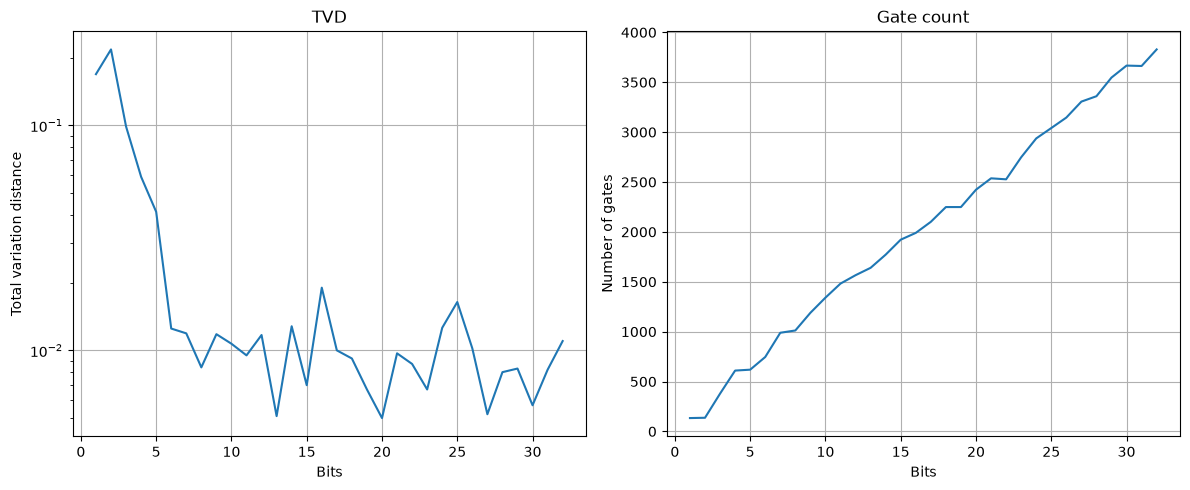

In [154]:
bits = np.arange(1, 33)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(bits, tv_results)
axes[0].set_yscale("log")
axes[0].set_xlabel("Bits")
axes[0].set_ylabel("Total variation distance")
axes[0].set_title("TVD")
axes[0].grid()

axes[1].plot(bits, gate_results)
axes[1].set_xlabel("Bits")
axes[1].set_ylabel("Number of gates")
axes[1].set_title("Gate count")
axes[1].grid()

plt.tight_layout()
plt.show()